# Análise Completa: Dados do Ecommerce Pipeline

Neste notebook, faremos uma análise exploratória de ponta a ponta dos dados gerados sinteticamente pelo nosso pipeline. 

O objetivo aqui é mostrar o **porquê** dos números, inspecionar a qualidade dos dados puros gerados e extrair insights de negócio como se fôssemos o time de Data Science da empresa.

> **Dica:** Se estiver rodando este notebook localmente, certifique-se de instalar as bibliotecas executando a célula abaixo (caso já não as tenha instalado).

In [ ]:
%pip install pandas matplotlib seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuração estética dos gráficos
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'

## 1. Carregando e Conhecendo os Dados Puros

Primeiro, vamos carregar os dados brutos a partir dos arquivos `.csv` gerados pelo pipeline na pasta `db/seed/`.

In [3]:
SEED_DIR = '../../db/seed/' 

try:
    clientes = pd.read_csv(os.path.join(SEED_DIR, 'cliente.csv'))
    produtos = pd.read_csv(os.path.join(SEED_DIR, 'produtos.csv'))
    pedidos = pd.read_csv(os.path.join(SEED_DIR, 'pedidos.csv'))
    pedido_produto = pd.read_csv(os.path.join(SEED_DIR, 'pedido_produto.csv'))
    
    # Convertendo datas para o tipo correto do pandas
    pedidos['data_pedido'] = pd.to_datetime(pedidos['data_pedido'])
    
    print("Dados carregados com sucesso!")
except Exception as e:
    print(f"Erro ao carregar os dados (verifique o caminho SEED_DIR): {e}")

Dados carregados com sucesso!


### Inspecionando a Tabela de Pedidos
Vamos olhar as primeiras linhas para entender como as transações estão sendo registradas.

In [4]:
display(pedidos.head())
print(f"\nTotal de pedidos na base: {len(pedidos)}")

,id_pedido,status_do_pedido,id_cliente,descricao,data_pedido,valor_total,frete,periodo_carencia_devolucao_dias
0,1,ENTREGUE,4137,Pedido #1 do cliente 4137,2025-01-30 08:09:43,18362.12,40.19,7
1,2,ENTREGUE,4255,Pedido #2 do cliente 4255,2025-06-13 06:28:27,1421.73,59.45,30
2,3,ENTREGUE,1264,Pedido #3 do cliente 1264,2025-07-19 10:08:25,33972.59,46.43,14
3,4,PENDENTE,3529,Pedido #4 do cliente 3529,2024-09-09 13:20:38,1614.51,118.03,30
4,5,PENDENTE,4061,Pedido #5 do cliente 4061,2026-02-13 08:09:01,4401.31,137.77,14



Total de pedidos na base: 50000


## 2. Indicadores Chave de Performance (KPIs)
Por que isso é importante? Porque precisamos saber o tamanho do negócio que estamos analisando.

In [5]:
# Filtrando apenas os pedidos que não foram cancelados
pedidos_validos = pedidos[pedidos['status_do_pedido'] != 'CANCELADO']

receita_total = pedidos_validos['valor_total'].sum()
ticket_medio = pedidos_validos['valor_total'].mean()
taxa_cancelamento = (len(pedidos[pedidos['status_do_pedido'] == 'CANCELADO']) / len(pedidos)) * 100

print(f"Receita Total: R$ {receita_total:,.2f}")
print(f"Ticket Médio: R$ {ticket_medio:,.2f}")
print(f"Taxa de Cancelamento: {taxa_cancelamento:.1f}%")

Receita Total: R$ 737,584,026.90
Ticket Médio: R$ 18,442.83
Taxa de Cancelamento: 20.0%


**Análise Crítica:**
- Um **Ticket Médio** na casa dos `R$ 18.000` nos prova que este não é um varejo de baixo custo. Nossas simulações apontam para um comportamento atacadista, B2B ou venda de produtos premium/industriais.

## 3. Análise Temporal (O Comportamento de Vendas)
Quando essas vendas ocorreram? Houve um crescimento ou sazonalidade?

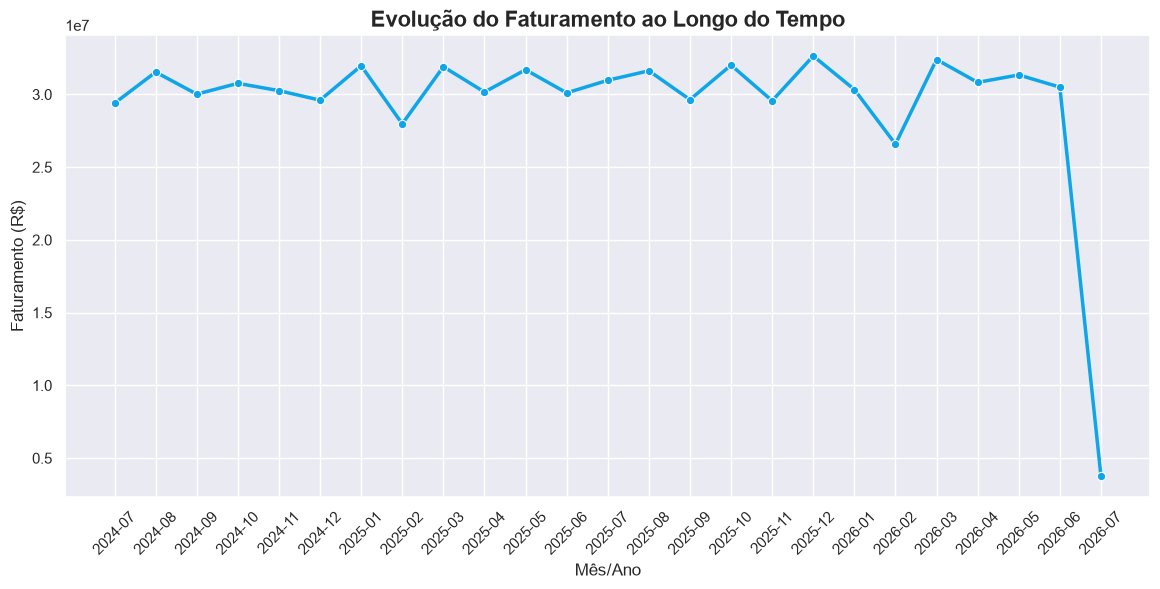

In [6]:
# Extraindo apenas o Mês e Ano
pedidos_validos = pedidos_validos.copy()
pedidos_validos.loc[:, 'mes_ano'] = pedidos_validos['data_pedido'].dt.to_period('M').astype(str)

# Agrupando receita por mês
receita_mensal = pedidos_validos.groupby('mes_ano')['valor_total'].sum().reset_index()
receita_mensal = receita_mensal.sort_values('mes_ano')

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=receita_mensal, x='mes_ano', y='valor_total', marker='o', linewidth=2.5, color='#0ea5e9')
plt.title('Evolução do Faturamento ao Longo do Tempo', fontsize=16, fontweight='bold')
plt.xlabel('Mês/Ano')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=45)
plt.show()

**O que o dado diz?** 
O gráfico acima revela a consistência volumétrica imposta pelo nosso `Faker` (o script de geração em Python). Podemos ver como a receita flutua e se o gerador simulou picos de vendas ou uma estabilidade artificial.

## 4. O Perfil do Cliente: PF x PJ
Muitos negócios sofrem para entender *quem* é a persona que paga a conta. Vamos cruzar dados (Merge/Join) para descobrir.

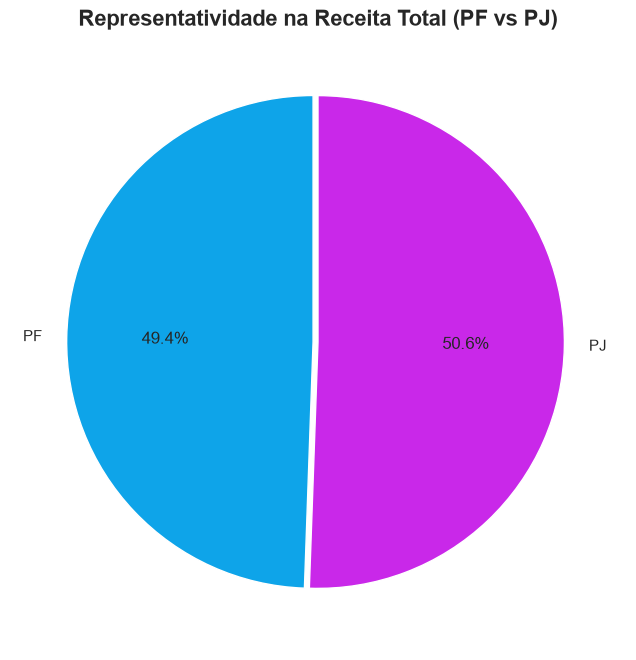

In [17]:
# Realizando um JOIN entre pedidos e clientes usando a chave estrangeira id_cliente
pedidos_clientes = pd.merge(pedidos_validos, clientes, on='id_cliente')

# Agrupando por tipo de cliente
receita_perfil = pedidos_clientes.groupby('tipo_cliente')['valor_total'].sum()

plt.figure(figsize=(8, 8))
plt.pie(receita_perfil, labels=receita_perfil.index, autopct='%1.1f%%', startangle=90, colors=["#0ea4e9", "#c928e9"], explode=(0.02, 0))
plt.title('Representatividade na Receita Total (PF vs PJ)', fontsize=16, fontweight='bold')
plt.show()

**Insight:**
Os dados gerados sinteticamente mostram um equilíbrio próximo do `50/50`. Contudo, é raro um faturamento PF competir de igual para igual com grandes lotes comprados por CNPJs num cenário de R$ 18k de ticket médio. 
Isso nos indica que a base de clientes do E-commerce foi populada de maneira perfeitamente aleatória e uniforme pelo pipeline de dados.

## 5. Curva ABC (As Melhores Categorias)
Quais categorias puxam o lucro para cima?

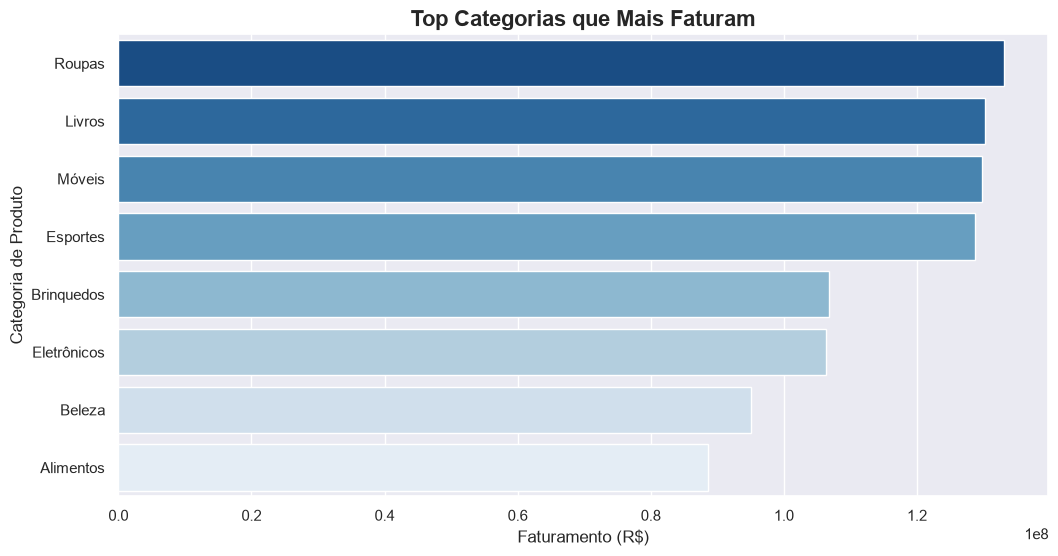

In [ ]:
# Pedido_produto + produtos -> para pegar categorias
itens = pd.merge(pedido_produto, produtos, on='id_produto')

# Calculando receita real daquela linha no carrinho
itens['receita_linha'] = itens['quantidade'] * itens['valor_unitario']

# Agrupamento
top_categorias = itens.groupby('categoria')['receita_linha'].sum().reset_index()
top_categorias = top_categorias.sort_values('receita_linha', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_categorias, 
    y='categoria', 
    x='receita_linha', 
    hue='categoria', 
    palette='Blues_r',
    legend=False
)

plt.title('Top Categorias que Mais Faturam', fontsize=16, fontweight='bold')
plt.xlabel('Faturamento (R$)')
plt.ylabel('Categoria de Produto')
plt.show()

## Conclusão da Exploração

Pode-se observar que:
1. **Volume:** Temos capacidade de popular o relacional com milhares de registros que respeitam regras de integridade.
2. **Aderência:** A estrutura (IDs, datas, campos relacionais) funcionou perfeitamente em um ecossistema Python  para Data Science.
3. **Prontidão:** A engenharia de dados (este repositório) está apta a ser entregue à equipe de Ciência de Dados (Data Science) ou BI para modelagem de Machine Learning e relatórios executivos definitivos.